In [2]:
#Assignment Part 1a , dataset = PJME_hourly.csv
#Import and Inspect the file

import pandas as pd

df = pd.read_csv("PJME_hourly.csv")     #   <---Enter Path

print(df.head())
print('-'*40)
print(df.shape)
print('-'*40)
print(df.columns)
print('-'*40)
print(df.dtypes)

              Datetime  PJME_MW
0  2002-12-31 01:00:00  26498.0
1  2002-12-31 02:00:00  25147.0
2  2002-12-31 03:00:00  24574.0
3  2002-12-31 04:00:00  24393.0
4  2002-12-31 05:00:00  24860.0
----------------------------------------
(145366, 2)
----------------------------------------
Index(['Datetime', 'PJME_MW'], dtype='str')
----------------------------------------
Datetime        str
PJME_MW     float64
dtype: object


In [3]:
#Looking for nulls and duplicates
print(df.isnull().sum())
print('-'*15)
print(df.duplicated().sum())

Datetime    0
PJME_MW     0
dtype: int64
---------------
0


In [4]:
#Time and date column is stored as text. We better convert it to proper pandas DateTime.
#Data enrichment

df['Datetime'] = pd.to_datetime(df['Datetime'])

print(df.dtypes)
print('-'*40)
print(df['Datetime'].min())
print(df['Datetime'].max())

Datetime    datetime64[us]
PJME_MW            float64
dtype: object
----------------------------------------
2002-01-01 01:00:00
2018-08-03 00:00:00


In [5]:
#Allocating rows to Customers.

import numpy as np

student_id = 13011619

def allocate_customer_segments(df, student_id):
    """
    Allocates 3 different energy customer profiles to the dataset
    with probability weights unique my ID.
    """

    # 1. Use my ID to create a unique probability drift factor
    drift = ((student_id % 5) - 2) * 0.05

    # 2. Define ID-driven probability distributions for each class
    prob_commercial = 0.40 + drift
    prob_residential = 0.35 - drift
    prob_industrial = 1.0 - (prob_commercial + prob_residential)

    weights = [prob_commercial, prob_residential, prob_industrial]
    categories = ['Commercial', 'Residential', 'Industrial']

    # 3. Seed numpy and randomly assign rows based on the custom weights
    np.random.seed(student_id)

    df['Customer_Segment'] = np.random.choice(
        categories,
        size=len(df),
        p=weights
    )

    # Print the allocation map
    print(f"\nCustomer Segment Allocation for ID {student_id}:")
    print(df['Customer_Segment'].value_counts(normalize=True).round(3) * 100)

    return df


df = allocate_customer_segments(df, student_id)

print('-' * 40)
print(df.head())


Customer Segment Allocation for ID 13011619:
Customer_Segment
Commercial     50.0
Industrial     25.0
Residential    25.0
Name: proportion, dtype: float64
----------------------------------------
             Datetime  PJME_MW Customer_Segment
0 2002-12-31 01:00:00  26498.0       Commercial
1 2002-12-31 02:00:00  25147.0       Commercial
2 2002-12-31 03:00:00  24574.0      Residential
3 2002-12-31 04:00:00  24393.0       Commercial
4 2002-12-31 05:00:00  24860.0      Residential


In [6]:
#Creating the new columns based on assignment formulas

df['Month'] = df['Datetime'].dt.month
df['Hour'] = df['Datetime'].dt.hour
df['Month_sin'] = np.sin((2 * np.pi * df['Month']) / 12) * 3
df['Month_cos'] = np.cos((2 * np.pi * df['Month']) / 12) * 2

print(df[['Datetime', 'Month', 'Hour', 'Month_sin', 'Month_cos']].head())

             Datetime  Month  Hour     Month_sin  Month_cos
0 2002-12-31 01:00:00     12     1 -7.347881e-16        2.0
1 2002-12-31 02:00:00     12     2 -7.347881e-16        2.0
2 2002-12-31 03:00:00     12     3 -7.347881e-16        2.0
3 2002-12-31 04:00:00     12     4 -7.347881e-16        2.0
4 2002-12-31 05:00:00     12     5 -7.347881e-16        2.0


In [7]:
# Student-specific factors for T_base

S = student_id

alpha_s = 15 + (student_id % 7) - 3
beta_s = 12 + (S % 5) * 0.5
gamma = 5
phi_s1 = 5 + (student_id % 4)
phi_s2 = 6 + (student_id % 4)

# Creating T_base using the corrected assignment formula

df['T_base'] = (
    alpha_s
    +
    beta_s * np.sin((2 * np.pi * (df['Month'] - phi_s1)) / 12)
    +
    gamma * np.sin((2 * np.pi * (df['Hour'] - phi_s2)) / 24)
)

print("alpha_s:", alpha_s)
print("beta_s:", beta_s)
print("gamma:", gamma)
print("phi_s1:", phi_s1)
print("phi_s2:", phi_s2)

print('-' * 40)
print(df[['Datetime', 'Month', 'Hour', 'T_base']].head())

alpha_s: 17
beta_s: 14.0
gamma: 5
phi_s1: 8
phi_s2: 9
----------------------------------------
             Datetime  Month  Hour     T_base
0 2002-12-31 01:00:00     12     1  24.794229
1 2002-12-31 02:00:00     12     2  24.294727
2 2002-12-31 03:00:00     12     3  24.124356
3 2002-12-31 04:00:00     12     4  24.294727
4 2002-12-31 05:00:00     12     5  24.794229


In [8]:
# Creating the random error term, standard deviation = 1.5

np.random.seed(student_id)

df['Error_e'] = np.random.normal(
    loc=0,
    scale=1.5,
    size=len(df))

print(df[['Datetime', 'T_base', 'Error_e']].head())

             Datetime     T_base   Error_e
0 2002-12-31 01:00:00  24.794229 -4.149430
1 2002-12-31 02:00:00  24.294727  3.296990
2 2002-12-31 03:00:00  24.124356 -0.970378
3 2002-12-31 04:00:00  24.294727  0.001436
4 2002-12-31 05:00:00  24.794229  2.265830


In [9]:
df['Temperature'] = df['T_base'] + df['Error_e']

print(df[['Datetime', 'T_base', 'Error_e', 'Temperature']].head())

             Datetime     T_base   Error_e  Temperature
0 2002-12-31 01:00:00  24.794229 -4.149430    20.644798
1 2002-12-31 02:00:00  24.294727  3.296990    27.591717
2 2002-12-31 03:00:00  24.124356 -0.970378    23.153978
3 2002-12-31 04:00:00  24.294727  0.001436    24.296162
4 2002-12-31 05:00:00  24.794229  2.265830    27.060058


In [10]:
print(df.head())

             Datetime  PJME_MW Customer_Segment  Month  Hour     Month_sin  \
0 2002-12-31 01:00:00  26498.0       Commercial     12     1 -7.347881e-16   
1 2002-12-31 02:00:00  25147.0       Commercial     12     2 -7.347881e-16   
2 2002-12-31 03:00:00  24574.0      Residential     12     3 -7.347881e-16   
3 2002-12-31 04:00:00  24393.0       Commercial     12     4 -7.347881e-16   
4 2002-12-31 05:00:00  24860.0      Residential     12     5 -7.347881e-16   

   Month_cos     T_base   Error_e  Temperature  
0        2.0  24.794229 -4.149430    20.644798  
1        2.0  24.294727  3.296990    27.591717  
2        2.0  24.124356 -0.970378    23.153978  
3        2.0  24.294727  0.001436    24.296162  
4        2.0  24.794229  2.265830    27.060058  


In [11]:
#Client Baseline Consumption

baseline_profile = df.groupby('Customer_Segment')['PJME_MW'].agg(
    Mean='mean',
    Median='median',
    Std_Dev='std',
    Minimum='min',
    Maximum='max'
)

print(baseline_profile)

                          Mean   Median      Std_Dev  Minimum  Maximum
Customer_Segment                                                      
Commercial        32081.543818  31427.0  6471.439514  14821.0  61796.0
Industrial        32111.198692  31413.0  6506.235327  14544.0  61770.0
Residential       32046.584846  31419.0  6406.536075  15390.0  62009.0


In [12]:
#Hourly profile data

hourly_profile = df.groupby(
    ['Hour', 'Customer_Segment']
)['PJME_MW'].mean().reset_index()

print(hourly_profile.head(15))

    Hour Customer_Segment       PJME_MW
0      0       Commercial  29508.017787
1      0       Industrial  29574.741828
2      0      Residential  29504.358081
3      1       Commercial  27542.363908
4      1       Industrial  27635.428193
5      1      Residential  27424.251625
6      2       Commercial  26338.204394
7      2       Industrial  26372.548471
8      2      Residential  26326.680583
9      3       Commercial  25699.949400
10     3       Industrial  25568.533647
11     3      Residential  25747.040761
12     4       Commercial  25353.287869
13     4       Industrial  25345.393758
14     4      Residential  25599.005102


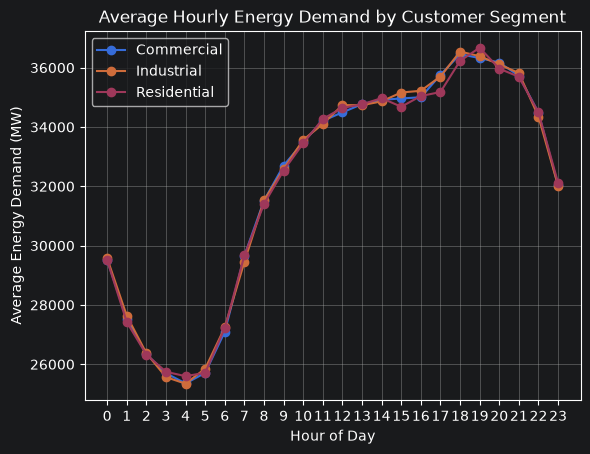

In [13]:
#Visualizing Hourly Demand

import matplotlib.pyplot as plt

for segment in hourly_profile['Customer_Segment'].unique():
    data = hourly_profile[hourly_profile['Customer_Segment'] == segment]
    plt.plot(data['Hour'], data['PJME_MW'], marker='o', label=segment)

plt.title('Average Hourly Energy Demand by Customer Segment')
plt.xlabel('Hour of Day')
plt.ylabel('Average Energy Demand (MW)')
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.show()

          Day Customer_Segment       PJME_MW
3      Monday       Commercial  32672.567609
4      Monday       Industrial  32652.578577
5      Monday      Residential  32690.175947
17    Tuesday      Residential  33185.025641
16    Tuesday       Industrial  33276.104432
15    Tuesday       Commercial  33314.809934
20  Wednesday      Residential  33255.736942
18  Wednesday       Commercial  33215.009803
19  Wednesday       Industrial  33359.515875
14   Thursday      Residential  33024.501834
13   Thursday       Industrial  33195.262311
12   Thursday       Commercial  33061.483918
0      Friday       Commercial  32666.019625
2      Friday      Residential  32651.258178
1      Friday       Industrial  32768.172117
8    Saturday      Residential  30165.094473
7    Saturday       Industrial  30116.077084
6    Saturday       Commercial  30185.517371
9      Sunday       Commercial  29456.682842
11     Sunday      Residential  29310.084866
10     Sunday       Industrial  29424.970213


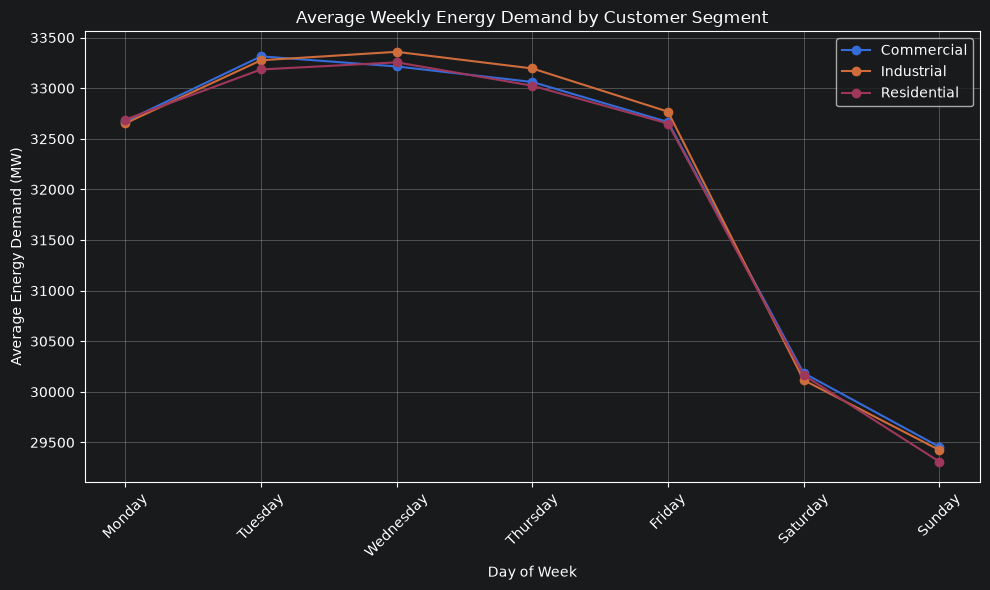

In [14]:
#Weekly Analysis.

import matplotlib.pyplot as plt

  #1. Variable "Day" from Datetime


df['Day'] = df['Datetime'].dt.day_name()

  #2. Day Order sort

day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday']

weekly_profile = df.groupby(
    ['Day', 'Customer_Segment']
)['PJME_MW'].mean().reset_index()

weekly_profile['Day'] = pd.Categorical(
    weekly_profile['Day'],
    categories=day_order,
    ordered=True)

weekly_profile = weekly_profile.sort_values('Day')

print(weekly_profile)


  #3. Visualizing the Weekly demand.

plt.figure(figsize=(10, 6))
for segment in weekly_profile['Customer_Segment'].unique():
    data = weekly_profile[weekly_profile['Customer_Segment'] == segment]

    plt.plot(
        data['Day'],
        data['PJME_MW'],
        marker='o',
        label=segment)

plt.title('Average Weekly Energy Demand by Customer Segment')
plt.xlabel('Day of Week')
plt.ylabel('Average Energy Demand (MW)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

    Month Customer_Segment       PJME_MW
0       1       Commercial  34354.877420
1       1       Industrial  34309.793254
2       1      Residential  34354.020964
3       2       Commercial  33405.562045
4       2       Industrial  33464.341833
5       2      Residential  33464.629565
6       3       Commercial  30451.372215
7       3       Industrial  30486.770266
8       3      Residential  30665.641907
9       4       Commercial  27876.042173
10      4       Industrial  27882.310016
11      4      Residential  27819.677649
12      5       Commercial  28672.760579
13      5       Industrial  28630.281260
14      5      Residential  28806.546751
15      6       Commercial  33780.688856
16      6       Industrial  33773.913849
17      6      Residential  33909.210560
18      7       Commercial  37887.179335
19      7       Industrial  38198.218720
20      7      Residential  37550.783871
21      8       Commercial  36613.824584
22      8       Industrial  36676.792103
23      8      R

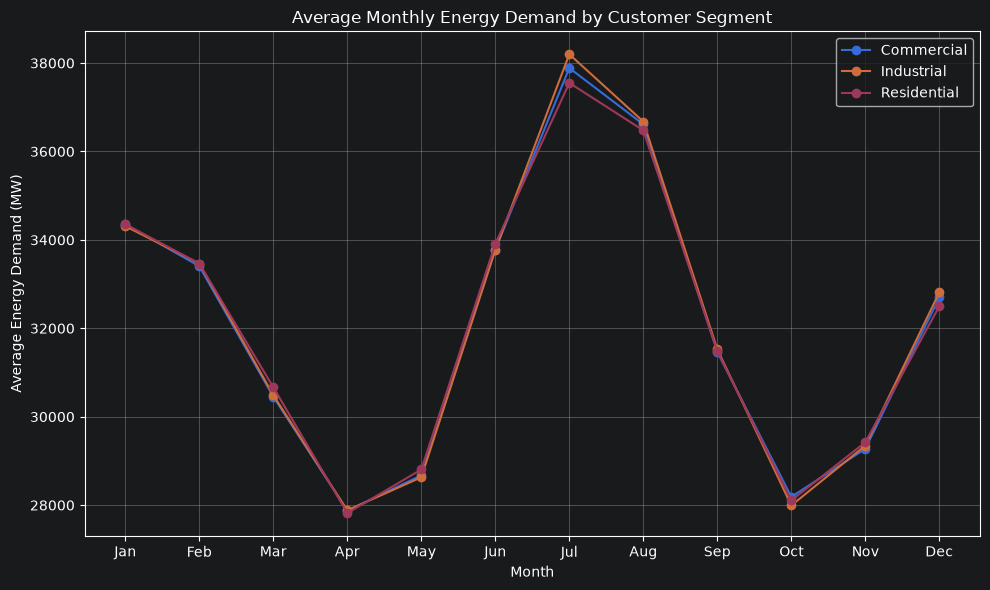

In [15]:
# Monthly Analysis

# 1. Monthly average demand by Customer Segment

monthly_profile = df.groupby(
    ['Month', 'Customer_Segment']
)['PJME_MW'].mean().reset_index()

print(monthly_profile)


# 2. Visualizing the Monthly demand

plt.figure(figsize=(10, 6))

for segment in monthly_profile['Customer_Segment'].unique():
    data = monthly_profile[monthly_profile['Customer_Segment'] == segment]

    plt.plot(
        data['Month'],
        data['PJME_MW'],
        marker='o',
        label=segment)

plt.title('Average Monthly Energy Demand by Customer Segment')
plt.xlabel('Month')
plt.ylabel('Average Energy Demand (MW)')
plt.xticks(
    range(1, 13),
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
# Thermal Meteorological Split - 2017

# 1. Creating the Year variable
df['Year'] = df['Datetime'].dt.year

# 2. Filtering one complete operational year
df_2017 = df[df['Year'] == 2017].copy()

print(df_2017[['Datetime', 'Year', 'Month', 'PJME_MW']].head())
print('-' * 50)
print(df_2017['Datetime'].min())
print(df_2017['Datetime'].max())
print(df_2017.shape)

                  Datetime  Year  Month  PJME_MW
122710 2017-01-01 00:00:00  2017      1  28171.0
131471 2017-12-31 01:00:00  2017     12  35242.0
131472 2017-12-31 02:00:00  2017     12  34410.0
131473 2017-12-31 03:00:00  2017     12  34150.0
131474 2017-12-31 04:00:00  2017     12  34220.0
--------------------------------------------------
2017-01-01 00:00:00
2017-12-31 23:00:00
(8760, 12)


In [17]:
# 3. Creating the seasonal groups

df_2017['Season'] = np.where(
    df_2017['Month'].isin([11, 12, 1, 2, 3, 4]),
    'Winter Peak',
    'Summer Peak'
)

print(df_2017['Season'].value_counts())

Season
Summer Peak    4416
Winter Peak    4344
Name: count, dtype: int64


In [18]:
# 4. Average hourly demand by Season and Customer Segment

seasonal_profile = df_2017.groupby(
    ['Hour', 'Season', 'Customer_Segment']
)['PJME_MW'].mean().reset_index()

print(seasonal_profile.head(20))

    Hour       Season Customer_Segment       PJME_MW
0      0  Summer Peak       Commercial  28495.989691
1      0  Summer Peak       Industrial  28471.129630
2      0  Summer Peak      Residential  29373.060606
3      0  Winter Peak       Commercial  27748.555556
4      0  Winter Peak       Industrial  28665.833333
5      0  Winter Peak      Residential  27972.714286
6      1  Summer Peak       Commercial  26566.057471
7      1  Summer Peak       Industrial  27204.146341
8      1  Summer Peak      Residential  26006.232143
9      1  Winter Peak       Commercial  26925.386364
10     1  Winter Peak       Industrial  26884.408163
11     1  Winter Peak      Residential  25691.250000
12     2  Summer Peak       Commercial  25010.455556
13     2  Summer Peak       Industrial  25234.125000
14     2  Summer Peak      Residential  25269.456522
15     2  Winter Peak       Commercial  26088.409091
16     2  Winter Peak       Industrial  26245.292683
17     2  Winter Peak      Residential  25014.

In [19]:
# 5. Average hourly demand by Season

season_comparison = df_2017.groupby(
    ['Hour', 'Season']
)['PJME_MW'].mean().reset_index()

print(season_comparison)

    Hour       Season       PJME_MW
0      0  Summer Peak  28645.994565
1      0  Winter Peak  28022.088398
2      1  Summer Peak  26537.858696
3      1  Winter Peak  26614.281768
4      2  Summer Peak  25133.554348
5      2  Winter Peak  25811.010989
6      3  Summer Peak  24263.494565
7      3  Winter Peak  25470.183333
8      4  Summer Peak  23816.755435
9      4  Winter Peak  25508.066298
10     5  Summer Peak  23971.358696
11     5  Winter Peak  26097.198895
12     6  Summer Peak  25063.967391
13     6  Winter Peak  27730.944751
14     7  Summer Peak  26962.021739
15     7  Winter Peak  30288.541436
16     8  Summer Peak  28755.288043
17     8  Winter Peak  31699.635359
18     9  Summer Peak  30204.309783
19     9  Winter Peak  31948.436464
20    10  Summer Peak  31488.179348
21    10  Winter Peak  31822.629834
22    11  Summer Peak  32694.152174
23    11  Winter Peak  31604.911602
24    12  Summer Peak  33680.032609
25    12  Winter Peak  31240.690608
26    13  Summer Peak  34476

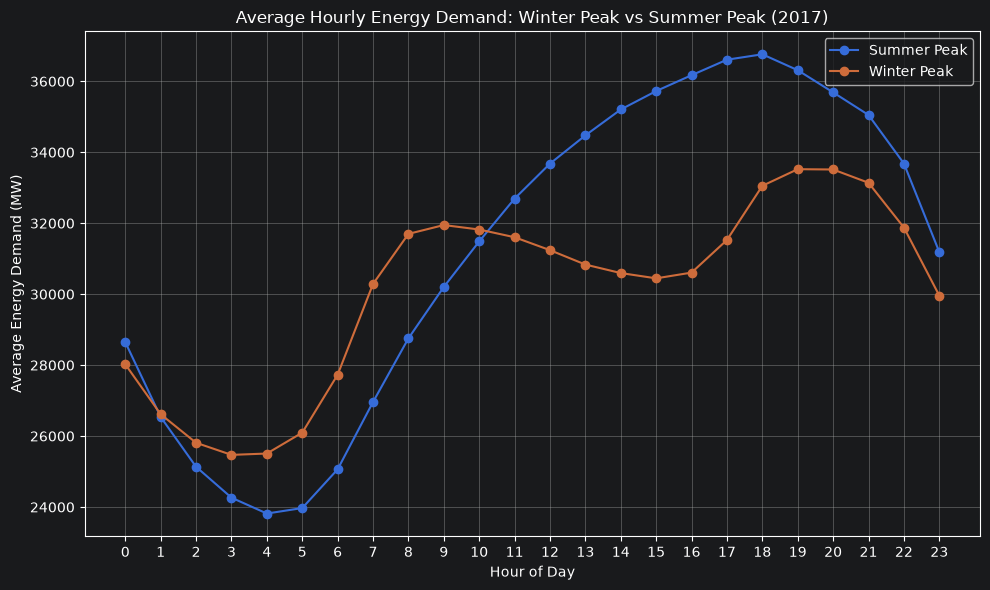

In [20]:
# 6. Visualizing Winter Peak vs Summer Peak

plt.figure(figsize=(10, 6))

for season in season_comparison['Season'].unique():
    data = season_comparison[season_comparison['Season'] == season]

    plt.plot(
        data['Hour'],
        data['PJME_MW'],
        marker='o',
        label=season)

plt.title('Average Hourly Energy Demand: Winter Peak vs Summer Peak (2017)')
plt.xlabel('Hour of Day')
plt.ylabel('Average Energy Demand (MW)')
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
# Weekday vs Weekend Analysis

# 1. Custom function to separate Weekdays and Weekends

def classify_day(day):
    if day >= 5:
        return 'Weekend'
    else:
        return 'Weekday'


df_2017['Day_Type'] = df_2017['Datetime'].dt.dayofweek.apply(classify_day)

print(df_2017[['Datetime', 'Day_Type']].head())
print('-' * 40)
print(df_2017['Day_Type'].value_counts())
print('-'*50)


# 2. Average hourly demand by Day Type and Customer Segment

weekday_weekend_profile = df_2017.groupby(
    ['Hour', 'Day_Type', 'Customer_Segment']
)['PJME_MW'].mean().reset_index()

print(weekday_weekend_profile.head(20))

                  Datetime Day_Type
122710 2017-01-01 00:00:00  Weekend
131471 2017-12-31 01:00:00  Weekend
131472 2017-12-31 02:00:00  Weekend
131473 2017-12-31 03:00:00  Weekend
131474 2017-12-31 04:00:00  Weekend
----------------------------------------
Day_Type
Weekday    6240
Weekend    2520
Name: count, dtype: int64
--------------------------------------------------
    Hour Day_Type Customer_Segment       PJME_MW
0      0  Weekday       Commercial  28238.208633
1      0  Weekday       Industrial  28134.264706
2      0  Weekday      Residential  28977.245283
3      0  Weekend       Commercial  27841.041667
4      0  Weekend       Industrial  29581.285714
5      0  Weekend      Residential  27730.344828
6      1  Weekday       Commercial  26959.741379
7      1  Weekday       Industrial  27050.666667
8      1  Weekday      Residential  25615.102564
9      1  Weekend       Commercial  26327.983051
10     1  Weekend       Industrial  26973.416667
11     1  Weekend      Residential  2

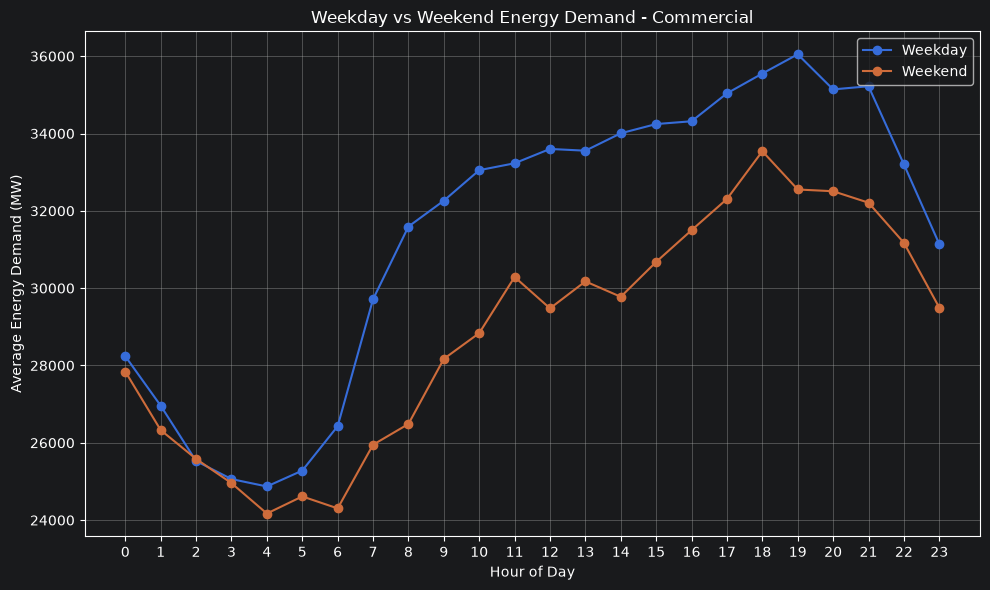

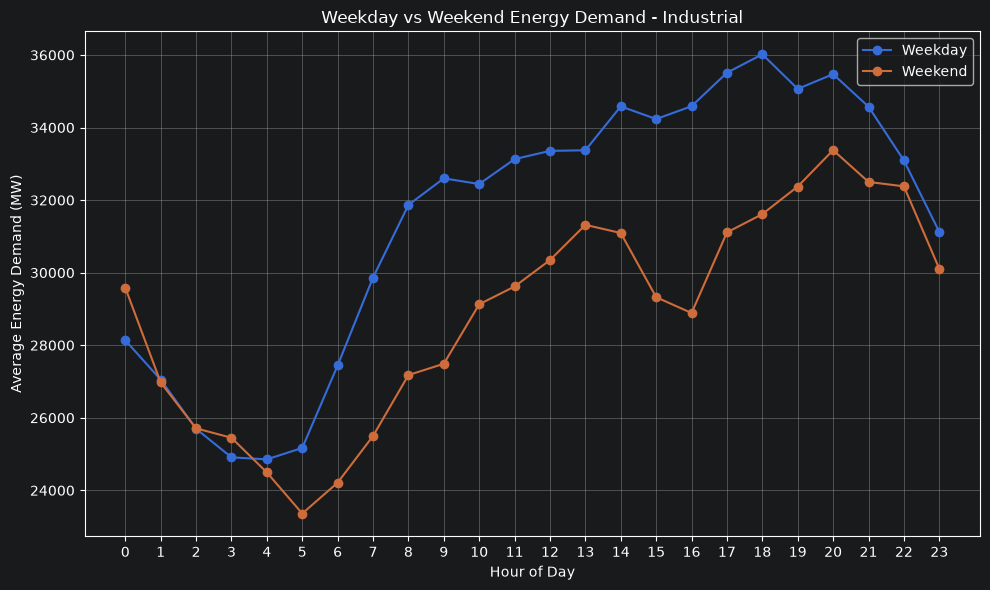

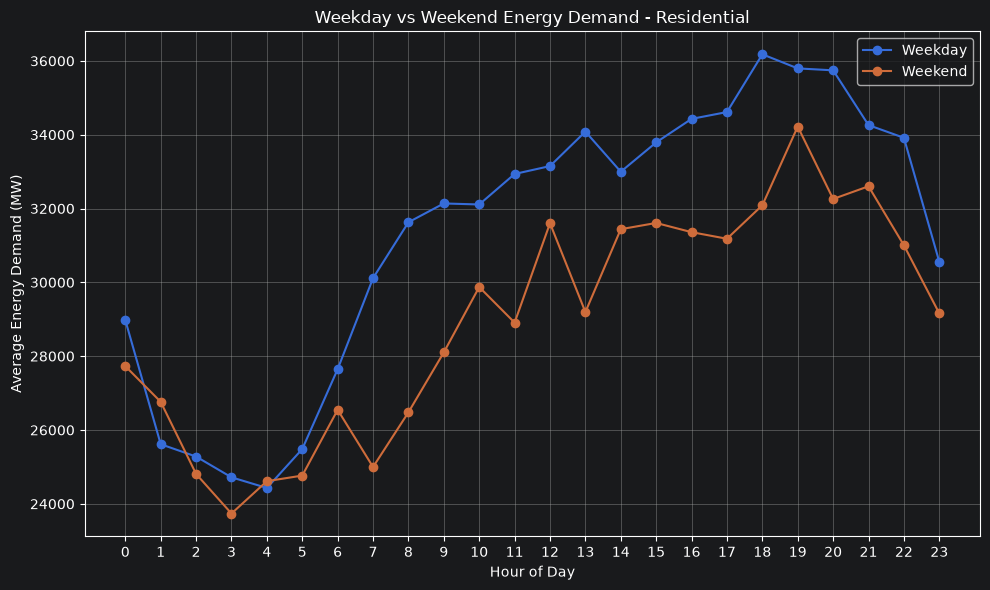

In [22]:
# 3. Visualizing Weekday vs Weekend for each Customer Segment

segments = ['Commercial', 'Industrial', 'Residential']

for segment in segments:

    segment_data = weekday_weekend_profile[
        weekday_weekend_profile['Customer_Segment'] == segment]

    plt.figure(figsize=(10, 6))

    for day_type in ['Weekday', 'Weekend']:

        data = segment_data[
            segment_data['Day_Type'] == day_type]

        plt.plot(
            data['Hour'],
            data['PJME_MW'],
            marker='o',
            label=day_type)

    plt.title(f'Weekday vs Weekend Energy Demand - {segment}')
    plt.xlabel('Hour of Day')
    plt.ylabel('Average Energy Demand (MW)')
    plt.xticks(range(24))
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [23]:
# Part 1b - Operational Clustering

# 1. Selecting features for clustering

cluster_data = df[
    ['PJME_MW', 'Temperature', 'Month_sin', 'Month_cos']
].copy()

print(cluster_data.head())
print('-' * 40)
print(cluster_data.shape)
print(cluster_data.dtypes)

   PJME_MW  Temperature     Month_sin  Month_cos
0  26498.0    20.644798 -7.347881e-16        2.0
1  25147.0    27.591717 -7.347881e-16        2.0
2  24574.0    23.153978 -7.347881e-16        2.0
3  24393.0    24.296162 -7.347881e-16        2.0
4  24860.0    27.060058 -7.347881e-16        2.0
----------------------------------------
(145366, 4)
PJME_MW        float64
Temperature    float64
Month_sin      float64
Month_cos      float64
dtype: object


In [24]:
# 2. Scaling the clustering features

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_data)

print(scaled_data[:5])

[[-0.8635878   0.36416791 -0.01558754  1.42648997]
 [-1.07259184  1.01812124 -0.01558754  1.42648997]
 [-1.16123678  0.60037141 -0.01558754  1.42648997]
 [-1.18923806  0.70789179 -0.01558754  1.42648997]
 [-1.11699166  0.96807317 -0.01558754  1.42648997]]


In [25]:
# 3.1. Finding the optimal number of clusters - Elbow Method

from sklearn.cluster import KMeans

inertia = []

k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=student_id,
        n_init=10
    )

    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

print(inertia)

[357312.72663640126, 253472.7522518708, 188073.3775032672, 156138.26034603734, 133875.21247007058, 117476.6619692141, 105962.24698388012]


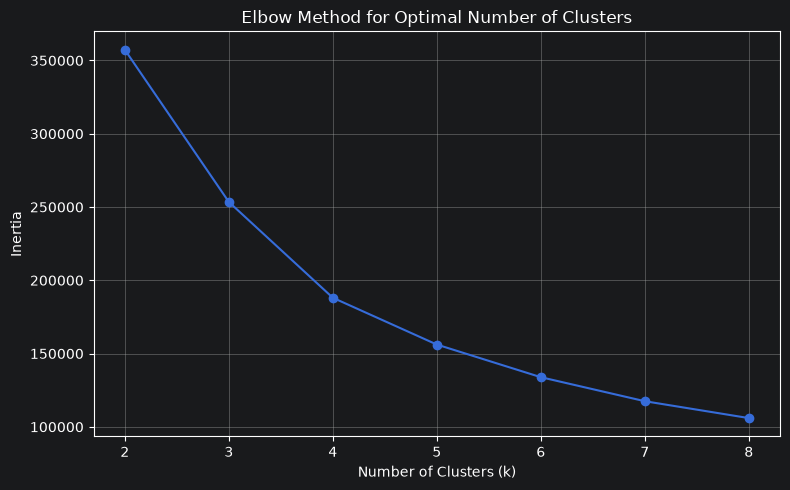

In [26]:
# 3.2. Plot - Elbow

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    inertia,
    marker='o'
)

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()

[0.36520636898444925, 0.38859396530990137, 0.3849570889784479, 0.3553684574795524, 0.33750111383385467, 0.32980522686695424, 0.3184043835947548]


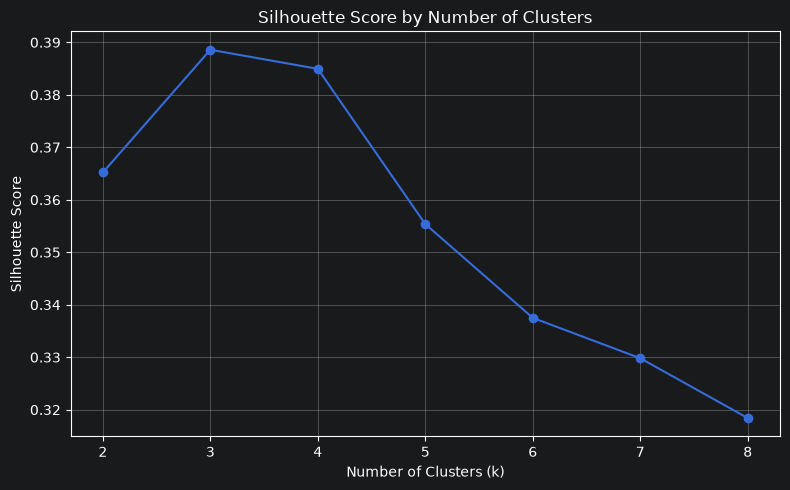

In [27]:
# 4.1. Silhouette Score for optimal number of clusters

from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=student_id,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(scaled_data)

    score = silhouette_score(
        scaled_data,
        cluster_labels,
        sample_size=10000,
        random_state=student_id
    )

    silhouette_scores.append(score)

print(silhouette_scores)

# 4.2. Silhouette Score Visualization

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score by Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
# 5. Comparing k=3 and k=4 cluster solutions

kmeans_3 = KMeans(
    n_clusters=3,
    random_state=student_id,
    n_init=10
)

kmeans_4 = KMeans(
    n_clusters=4,
    random_state=student_id,
    n_init=10
)

labels_3 = kmeans_3.fit_predict(scaled_data)
labels_4 = kmeans_4.fit_predict(scaled_data)

comparison_data = cluster_data.copy()

comparison_data['Cluster_3'] = labels_3
comparison_data['Cluster_4'] = labels_4

print("K = 3 Cluster Sizes")
print(comparison_data['Cluster_3'].value_counts().sort_index())

print('-' * 40)

print("K = 4 Cluster Sizes")
print(comparison_data['Cluster_4'].value_counts().sort_index())
print("\nK = 3 Cluster Characteristics")
print(
    comparison_data.groupby('Cluster_3')[
        ['PJME_MW', 'Temperature', 'Month_sin', 'Month_cos']
    ].mean()
)

print('-' * 60)

print("\nK = 4 Cluster Characteristics")
print(
    comparison_data.groupby('Cluster_4')[
        ['PJME_MW', 'Temperature', 'Month_sin', 'Month_cos']
    ].mean()
)

K = 3 Cluster Sizes
Cluster_3
0    63588
1    51034
2    30744
Name: count, dtype: int64
----------------------------------------
K = 4 Cluster Sizes
Cluster_4
0    46072
1    35280
2    26811
3    37203
Name: count, dtype: int64

K = 3 Cluster Characteristics
                PJME_MW  Temperature  Month_sin  Month_cos
Cluster_3                                                 
0          31326.417453    26.727815  -0.644441   1.317769
1          28793.554023     6.347836   1.902546  -0.877161
2          39095.082065    13.504221  -1.669426  -1.380202
------------------------------------------------------------

K = 4 Cluster Characteristics
                PJME_MW  Temperature  Month_sin  Month_cos
Cluster_4                                                 
0          28446.689898     5.335258   1.768466  -1.109977
1          34060.362018    23.254617   1.441094   1.525998
2          40313.587072    13.435439  -1.605266  -1.431170
3          28768.664355    27.208856  -2.271021   0.86737

In [29]:
# 6. Final K-Means model with 3 clusters

final_kmeans = KMeans(
    n_clusters=3,
    random_state=student_id,
    n_init=10
)

df['Cluster'] = final_kmeans.fit_predict(scaled_data)

print(df['Cluster'].value_counts().sort_index())

Cluster
0    63588
1    51034
2    30744
Name: count, dtype: int64


In [30]:
# Part 1b - Team Characteristic Diagnostic

cluster_diagnostic = df.groupby('Cluster').agg(
    Observations=('PJME_MW', 'count'),
    Mean_Demand=('PJME_MW', 'mean'),
    Median_Demand=('PJME_MW', 'median'),
    Std_Demand=('PJME_MW', 'std'),
    Minimum_Demand=('PJME_MW', 'min'),
    Maximum_Demand=('PJME_MW', 'max'),
    Mean_Temperature=('Temperature', 'mean')
)

print(cluster_diagnostic.round(2))

         Observations  Mean_Demand  Median_Demand  Std_Demand  Minimum_Demand  \
Cluster                                                                         
0               63588     31326.42        31462.0     5122.58         14544.0   
1               51034     28793.55        28943.0     4190.62         19247.0   
2               30744     39095.08        38743.5     6769.42         23954.0   

         Maximum_Demand  Mean_Temperature  
Cluster                                    
0               49877.0             26.73  
1               43865.0              6.35  
2               62009.0             13.50  


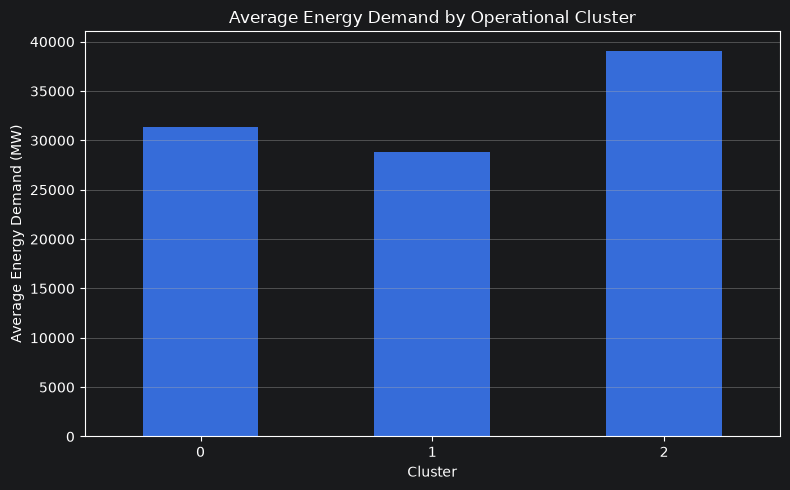

In [31]:
# Part 1b - Team Characteristic Diagnostic - Visualizing average demand by Cluster

cluster_mean_demand = df.groupby('Cluster')['PJME_MW'].mean()

plt.figure(figsize=(8, 5))

cluster_mean_demand.plot(kind='bar')

plt.title('Average Energy Demand by Operational Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Energy Demand (MW)')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

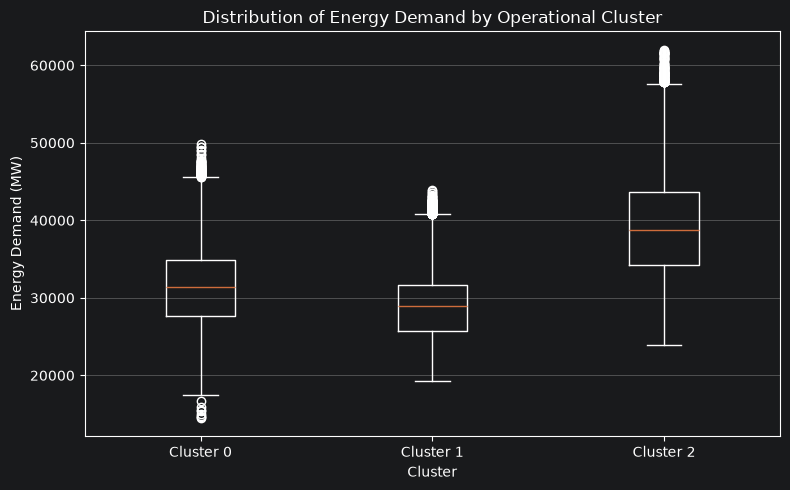

In [32]:
# Part 1b - Team Characteristic Diagnostic -  Distribution of Energy Demand by Cluster

cluster_values = [
    df[df['Cluster'] == 0]['PJME_MW'],
    df[df['Cluster'] == 1]['PJME_MW'],
    df[df['Cluster'] == 2]['PJME_MW']
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    cluster_values,
    tick_labels=['Cluster 0', 'Cluster 1', 'Cluster 2']
)

plt.title('Distribution of Energy Demand by Operational Cluster')
plt.xlabel('Cluster')
plt.ylabel('Energy Demand (MW)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [33]:
# Part 1b - Client Mapping & Impact

# 1. Assigning operational names to the clusters

cluster_names = {
    0: 'Normal / Moderate',
    1: 'Reduced Load',
    2: 'High Demand / System Strain'
}

df['Operational_State'] = df['Cluster'].map(cluster_names)


# 2. Customer distribution across operational states - Counts

client_cluster_counts = pd.crosstab(
    df['Customer_Segment'],
    df['Operational_State']
)

print("Customer Segment Counts by Operational State")
print(client_cluster_counts)

print('-' * 60)


# 3. Customer distribution across operational states - Percentages

client_cluster_percent = pd.crosstab(
    df['Customer_Segment'],
    df['Operational_State'],
    normalize='index'
) * 100

print("Customer Segment Percentage Distribution")
print(client_cluster_percent.round(2))

Customer Segment Counts by Operational State
Operational_State  High Demand / System Strain  Normal / Moderate  \
Customer_Segment                                                    
Commercial                               15505              31726   
Industrial                                7699              15940   
Residential                               7540              15922   

Operational_State  Reduced Load  
Customer_Segment                 
Commercial                25387  
Industrial                12749  
Residential               12898  
------------------------------------------------------------
Customer Segment Percentage Distribution
Operational_State  High Demand / System Strain  Normal / Moderate  \
Customer_Segment                                                    
Commercial                               21.35              43.69   
Industrial                               21.16              43.81   
Residential                              20.74              4

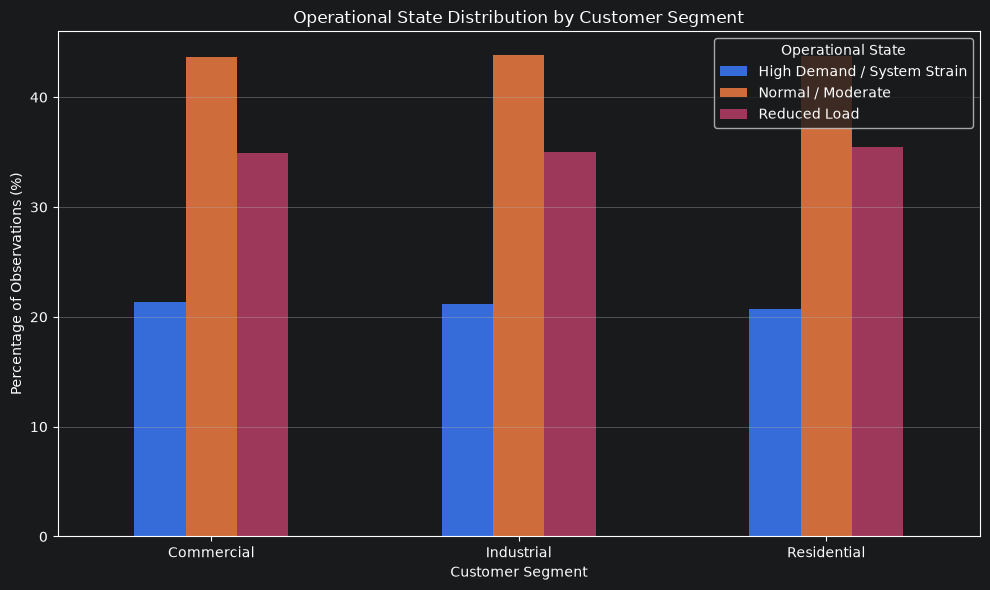

In [34]:
# Part 1b - Client Mapping & Impact

# 4. Visualizing Customer Segment distribution across Operational States

client_cluster_percent.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Operational State Distribution by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Percentage of Observations (%)')
plt.xticks(rotation=0)
plt.legend(title='Operational State')
plt.grid(axis='y')
plt.tight_layout()
plt.show()